In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/chaimaabid233/nids-week1-prompt3/prompt3_code.py
/kaggle/input/datasets/chaimaabid233/nids-week1-prompt2/prompt2_code.py
/kaggle/input/datasets/chaimaabid233/nids-week1-prompt1/prompt1_code.py
/kaggle/input/datasets/chaimaabid233/nids-week15-prompt4-fixed/prompt4_fixed.py
/kaggle/input/datasets/chaimaabid233/nids-week1-prompt4/prompt4_code.py
/kaggle/input/datasets/chaimaabid233/cicids2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/datasets/chaimaabid233/cicids2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/datasets/chaimaabid233/cicids2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chaimaabid233/cicids2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/datasets/chaimaabid233/cicids2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chaimaabid233/cicids2017/MachineLearningCVE/Frid

In [4]:
import numpy as np
import random
import pandas as pd
import os
import time

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

SAVE_DIR = '/kaggle/working/'

import pandas, sklearn
print(f"pandas: {pandas.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"numpy: {np.__version__}")
print(f"Random seed set: {SEED}")
print(f"Save directory: {SAVE_DIR}")

pandas: 2.3.3
sklearn: 1.6.1
numpy: 2.4.6
Random seed set: 42
Save directory: /kaggle/working/


pandas: 2.3.3
sklearn: 1.6.1
numpy: 2.4.6
Environment: Kaggle — saving to /kaggle/working/

STEP 1: Loading CSV files
  [OK utf-8]  Monday-WorkingHours.pcap_ISCX.csv  →  529,918 rows, 79 cols
  [OK utf-8]  Tuesday-WorkingHours.pcap_ISCX.csv  →  445,909 rows, 79 cols
  [OK utf-8]  Wednesday-workingHours.pcap_ISCX.csv  →  692,703 rows, 79 cols
  [OK utf-8]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  →  170,366 rows, 79 cols
  [OK utf-8]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  →  288,602 rows, 79 cols
  [OK utf-8]  Friday-WorkingHours-Morning.pcap_ISCX.csv  →  191,033 rows, 79 cols
  [OK utf-8]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  →  286,467 rows, 79 cols
  [OK utf-8]  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  →  225,745 rows, 79 cols

Step 1 completed in 55.5s

FINDING: 8 of 8 files loaded successfully.
  No encoding issues encountered.

STEP 2: Stripping whitespace from column names
  First file: Monday-WorkingHours.pcap_ISCX.

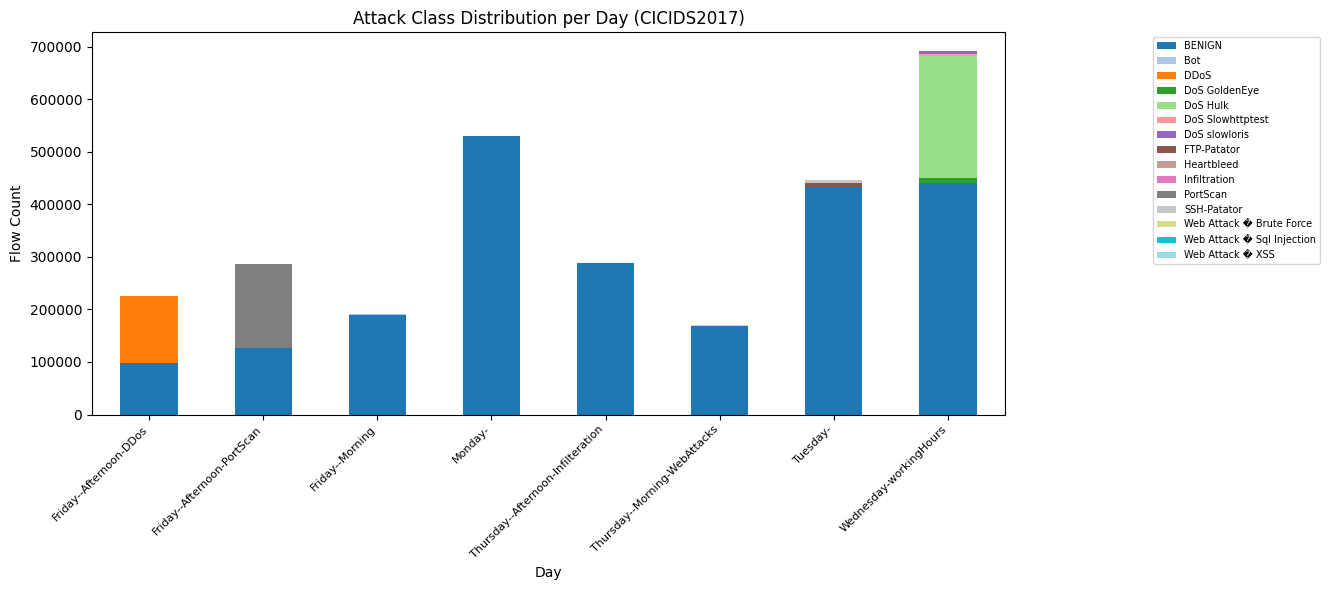

  Bar chart saved to /kaggle/working/attack_distribution_per_day.png

STEP 4: Concatenating all dataframes
  Final merged shape: (2830743, 80)
Step 4 completed in 1.1s

STEP 5: Label standardization
Labels BEFORE cleaning (sorted):
  'BENIGN'
  'Bot'
  'DDoS'
  'DoS GoldenEye'
  'DoS Hulk'
  'DoS Slowhttptest'
  'DoS slowloris'
  'FTP-Patator'
  'Heartbleed'
  'Infiltration'
  'PortScan'
  'SSH-Patator'
  'Web Attack � Brute Force'
  'Web Attack � Sql Injection'
  'Web Attack � XSS'

Label mapping (changed labels only):
  'BENIGN'  →  'Benign'
  'DDoS'  →  'Ddos'
  'DoS GoldenEye'  →  'Dos Goldeneye'
  'DoS Hulk'  →  'Dos Hulk'
  'DoS Slowhttptest'  →  'Dos Slowhttptest'
  'DoS slowloris'  →  'Dos Slowloris'
  'FTP-Patator'  →  'Ftp Patator'
  'PortScan'  →  'Portscan'
  'SSH-Patator'  →  'Ssh Patator'
  'Web Attack � XSS'  →  'Web Attack � Xss'

Labels AFTER cleaning (sorted):
  'Benign'
  'Bot'
  'Ddos'
  'Dos Goldeneye'
  'Dos Hulk'
  'Dos Slowhttptest'
  'Dos Slowloris'
  'Ftp Pata

In [5]:
 code = open('/kaggle/input/datasets/chaimaabid233/nids-week1-prompt1/prompt1_code.py').read()

# Fix 1: numpy name
code = code.replace('print(f"numpy: {numpy.__version__}")', 'print(f"numpy: {np.__version__}")')

# Fix 2: Replace the entire try/except environment block with Kaggle directly
import re
code = re.sub(
    r'try:.*?except ImportError:.*?print\("Environment: Kaggle.*?SAVE_DIR\)',
    'SAVE_DIR = \'/kaggle/working/\'\nENV = \'kaggle\'\nprint("Environment: Kaggle — saving to", SAVE_DIR)',
    code,
    flags=re.DOTALL
)

exec(code, globals())

Loading from current session
Loaded merged dataset: (2574264, 80)

X_train shape : (2059411, 78)
X_test  shape : (514853, 78)

Class distribution — TRAIN:
  Benign                                         1,718,709  (83.46%)
  Bot                                                1,562  ( 0.08%)
  Ddos                                             102,413  ( 4.97%)
  Dos Goldeneye                                      8,229  ( 0.40%)
  Dos Hulk                                         138,279  ( 6.71%)
  Dos Slowhttptest                                   4,182  ( 0.20%)
  Dos Slowloris                                      4,308  ( 0.21%)
  Ftp Patator                                        4,746  ( 0.23%)
  Heartbleed                                             9  ( 0.00%)
  Infiltration                                          29  ( 0.00%)
  Portscan                                          72,655  ( 3.53%)
  Ssh Patator                                        2,575  ( 0.13%)
  Web Attack � Br

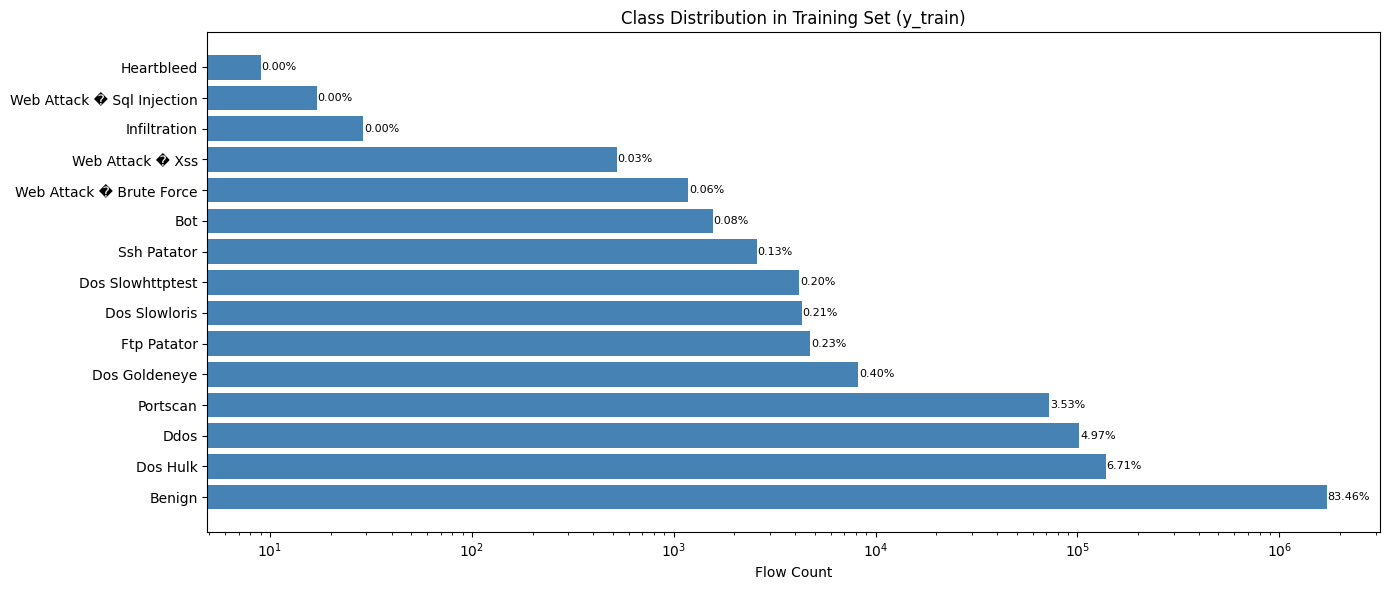


  Imbalance ratio (largest / smallest class): 190,967.7

  Dummy classifier (most_frequent) accuracy: 0.8346

  Classification report for dummy classifier:
                            precision    recall  f1-score   support

                    Benign       0.83      1.00      0.91    429677
                       Bot       0.00      0.00      0.00       391
                      Ddos       0.00      0.00      0.00     25603
             Dos Goldeneye       0.00      0.00      0.00      2057
                  Dos Hulk       0.00      0.00      0.00     34570
          Dos Slowhttptest       0.00      0.00      0.00      1046
             Dos Slowloris       0.00      0.00      0.00      1077
               Ftp Patator       0.00      0.00      0.00      1187
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  Portscan       0.00      0.00      0.00     18164
               Ssh Patator

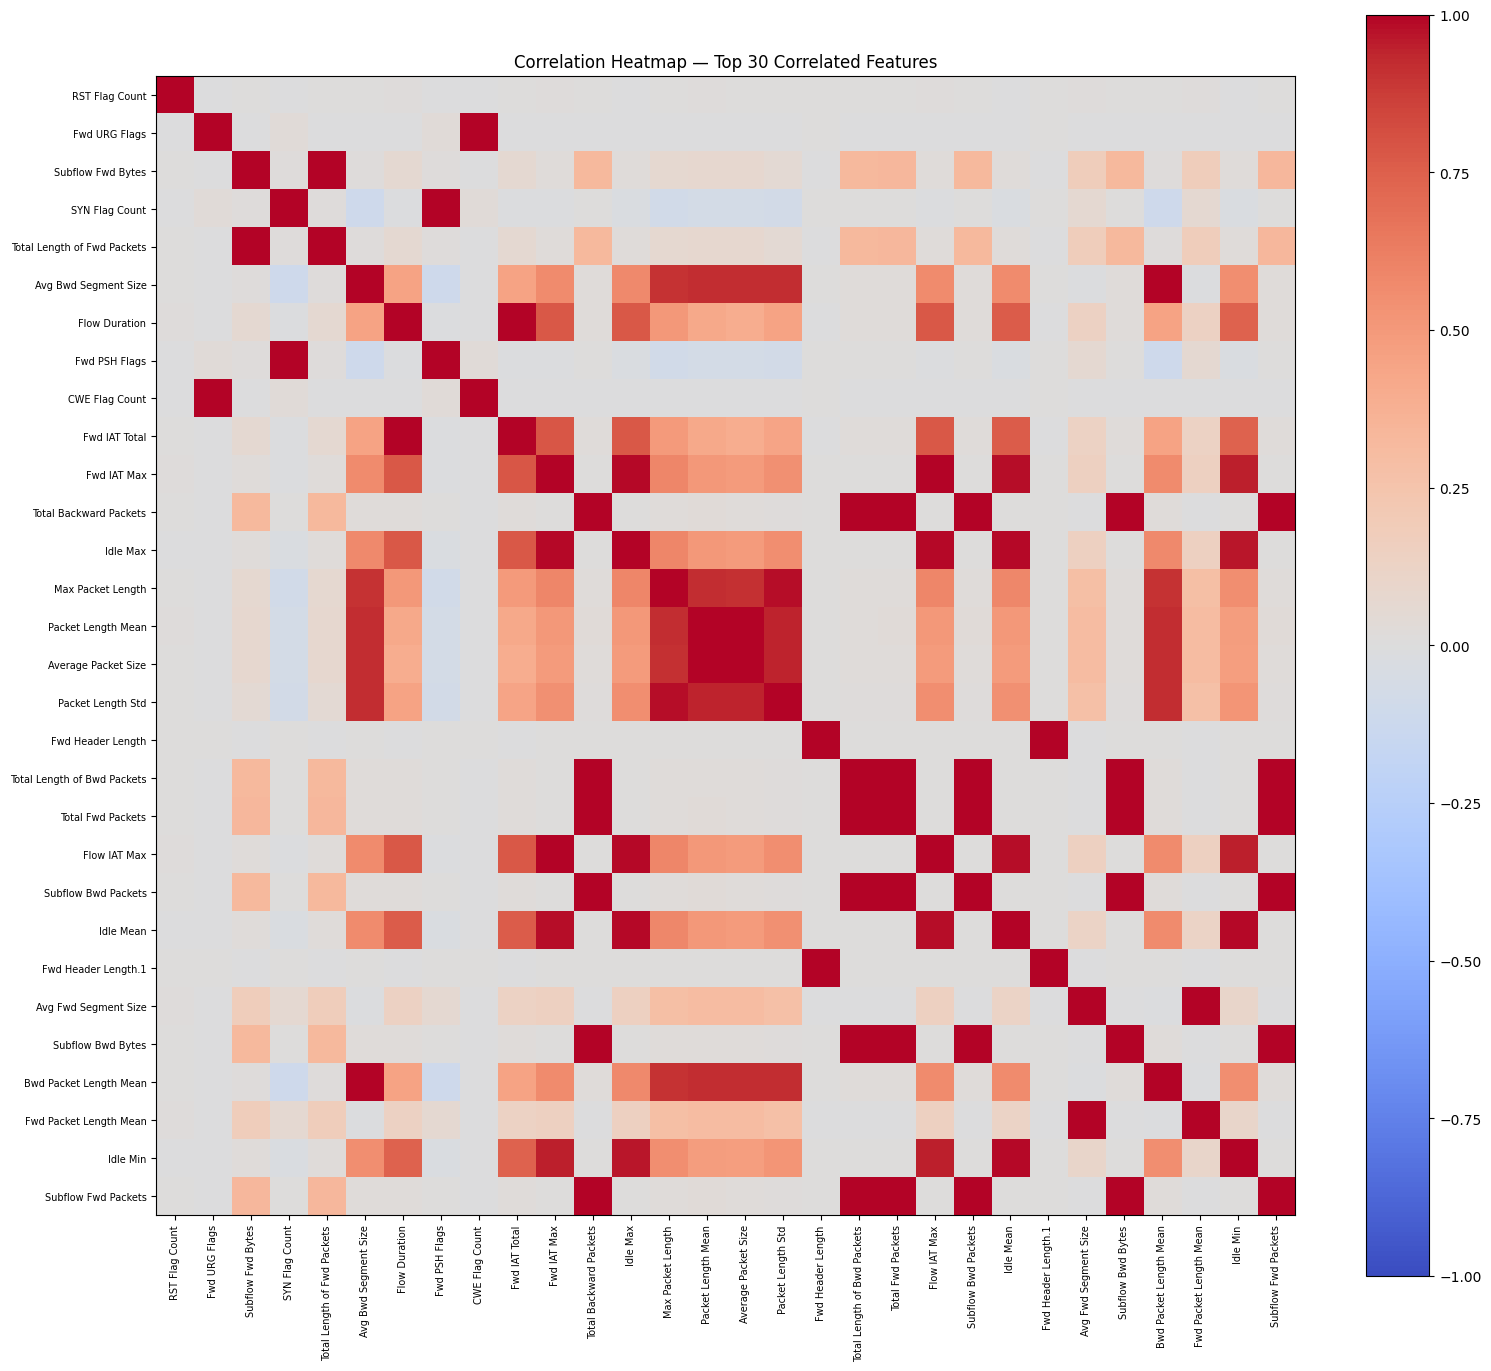


  Decision: Remove features with correlation > 0.95
  Justification: At 0.95 correlation two features measure essentially the same
  thing 95% of the time.
  For Random Forest this adds computation without benefit.
  For XGBoost this can cause overfitting by double-weighting the same signal.
  For the neural network in Week 3 multicollinearity destabilizes gradient descent.
  Threshold 0.95 chosen over 0.90 (too aggressive — removes features with 10%
  independent information) and 0.99 (too conservative — keeps near-duplicates).

  Features flagged for removal (23): ['Avg Bwd Segment Size', 'SYN Flag Count', 'Subflow Fwd Packets', 'CWE Flag Count', 'Avg Fwd Segment Size', 'Subflow Bwd Packets', 'Fwd Header Length.1', 'Subflow Bwd Bytes', 'Subflow Fwd Bytes', 'Total Backward Packets', 'Fwd IAT Total', 'ECE Flag Count', 'Fwd IAT Max', 'Average Packet Size', 'Total Length of Bwd Packets', 'Idle Max', 'Idle Min', 'Packet Length Std', 'Bwd Packet Length Std', 'Fwd Packets/s', 'Idle Mean', 

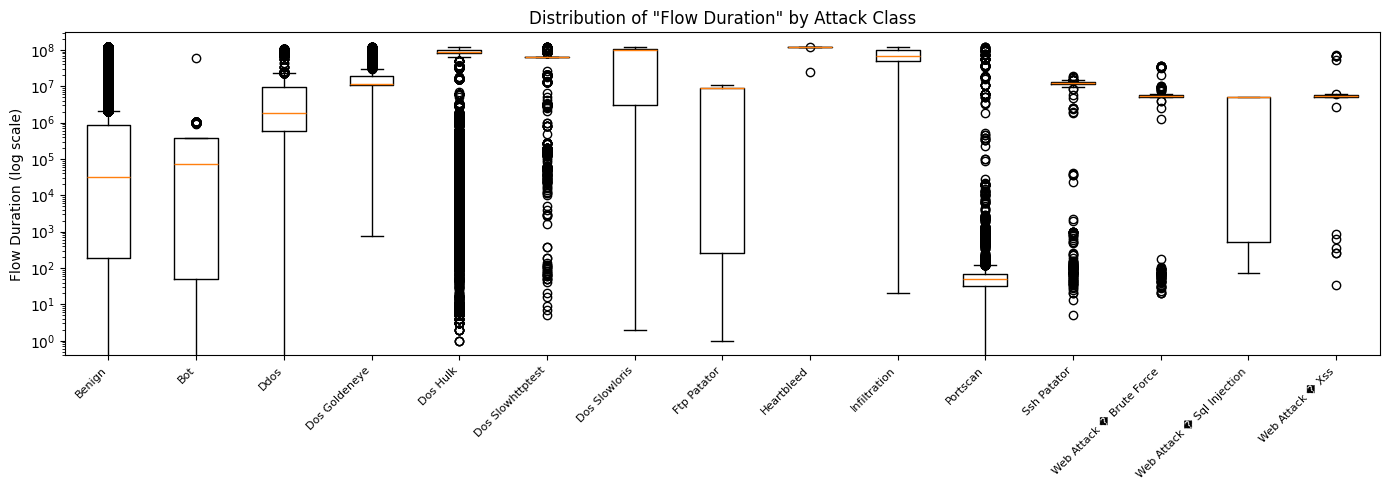


  Feature: Total Fwd Packets
  Mean per class:
    Benign                                   10.7222
    Bot                                      3.3073
    Ddos                                     4.4755
    Dos Goldeneye                            5.9426
    Dos Hulk                                 6.3562
    Dos Slowhttptest                         6.0053
    Dos Slowloris                            6.8203
    Ftp Patator                              6.6557
    Heartbleed                               2355.8000
    Infiltration                             623.2667
    Portscan                                 1.0290
    Ssh Patator                              19.5970
    Web Attack � Brute Force                 10.4762
    Web Attack � Sql Injection               3.5556
    Web Attack � Xss                         7.4636
  Cybersecurity note:
    Low packet count for BruteForce: CONFIRMED.
Each attempt: connect, send credentials, receive rejection, disconnect.
Minimal exchange.


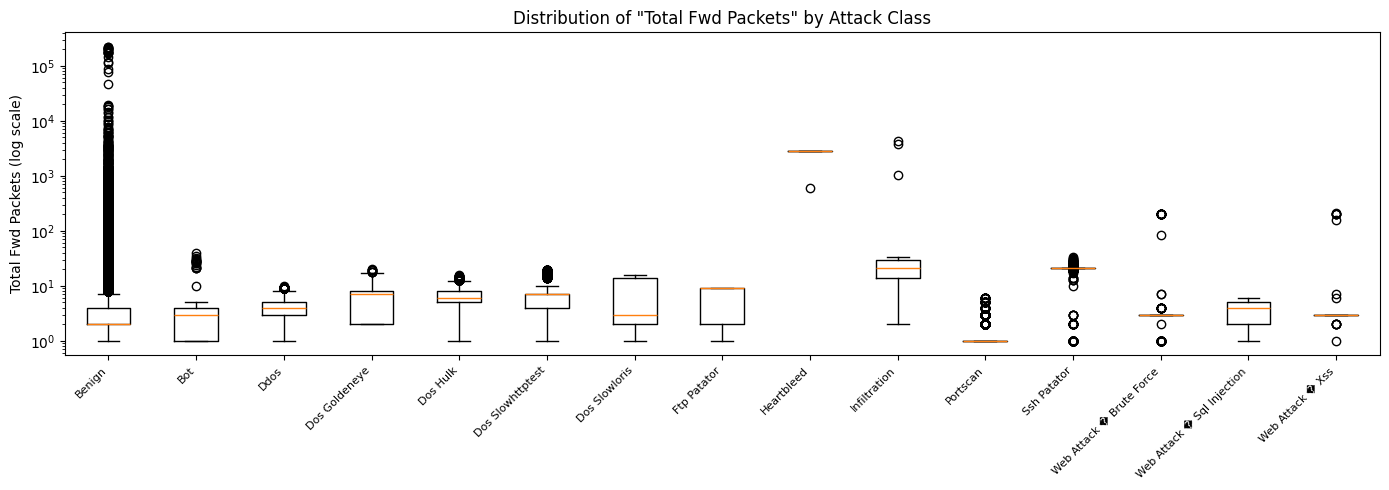


  Feature: Destination Port
  Mean per class:
    Benign                                   9823.7417
    Bot                                      17372.8464
    Ddos                                     82.5306
    Dos Goldeneye                            80.0000
    Dos Hulk                                 80.0000
    Dos Slowhttptest                         80.0000
    Dos Slowloris                            80.0000
    Ftp Patator                              21.0000
    Heartbleed                               444.0000
    Infiltration                             444.0000
    Portscan                                 8494.1535
    Ssh Patator                              22.0000
    Web Attack � Brute Force                 80.0000
    Web Attack � Sql Injection               80.0000
    Web Attack � Xss                         80.0000
  Cybersecurity note:
    Concentrated ports for BruteForce: CONFIRMED.
FTP-Patator targets port 21. SSH-Patator targets port 22.
Normal traffic uses

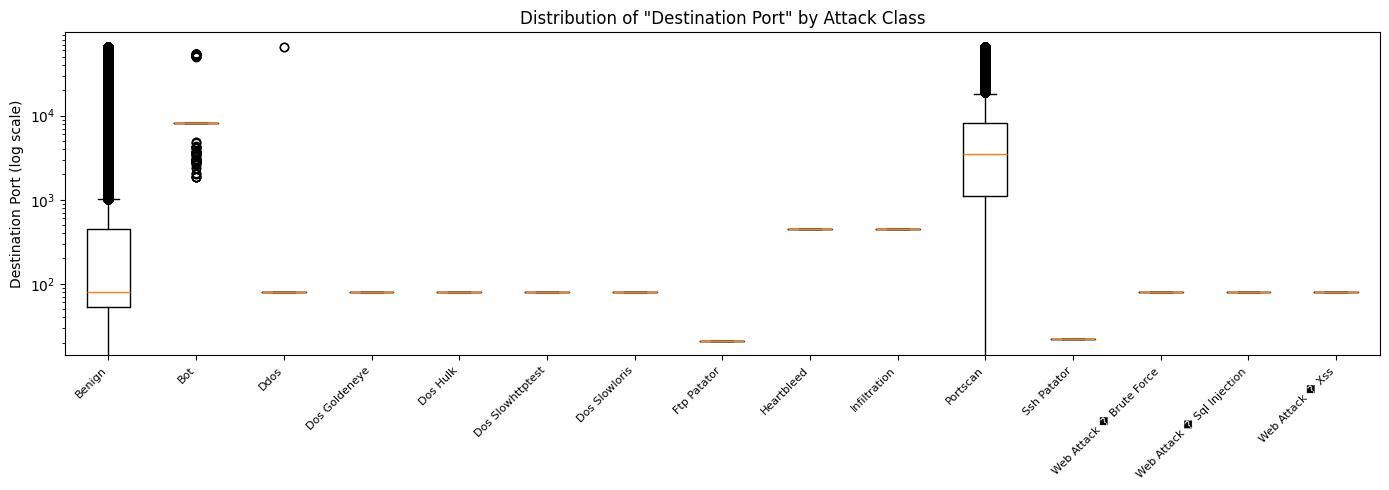


  Feature: SYN Flag Count
  Mean per class:
    Benign                                   0.0560
    Bot                                      0.0000
    Ddos                                     0.0000
    Dos Goldeneye                            0.0000
    Dos Hulk                                 0.0000
    Dos Slowhttptest                         0.1277
    Dos Slowloris                            0.2646
    Ftp Patator                              0.3304
    Heartbleed                               0.0000
    Infiltration                             0.6667
    Portscan                                 0.0000
    Ssh Patator                              0.0047
    Web Attack � Brute Force                 0.0000
    Web Attack � Sql Injection               0.0000
    Web Attack � Xss                         0.0000
  Cybersecurity note:
    High SYN for BruteForce: CONFIRMED by literature.
Each brute force attempt initiates new TCP handshake generating SYN flag.
Normal traffic reuses con

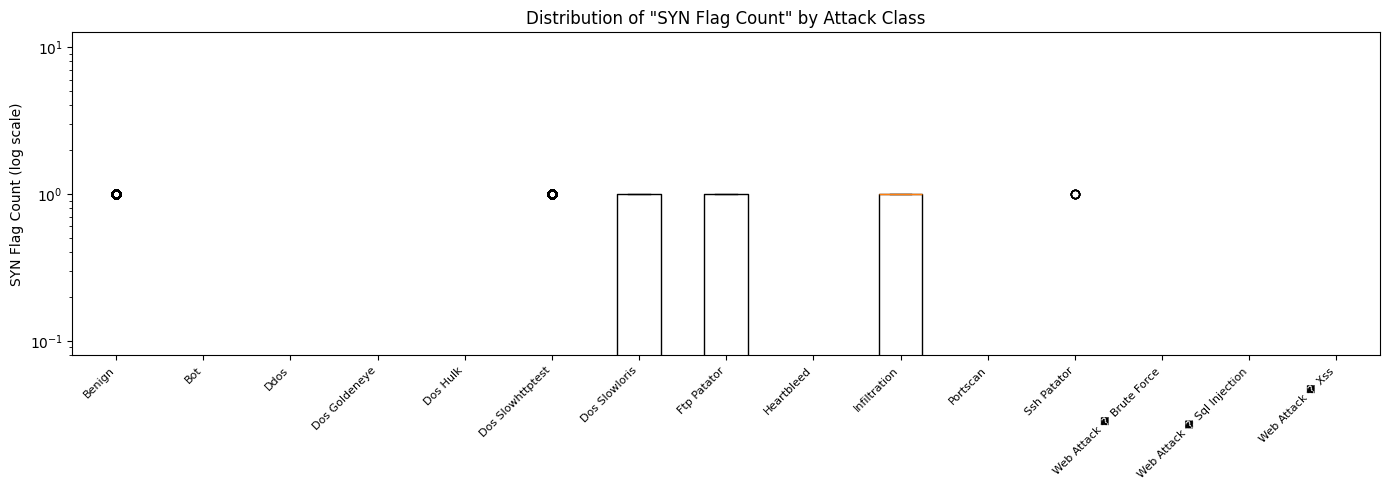


  Feature: Flow IAT Mean
  Mean per class:
    Benign                                   944763.4904
    Bot                                      60339.3334
    Ddos                                     1887721.7101
    Dos Goldeneye                            13907802.2946
    Dos Hulk                                 6378075.9628
    Dos Slowhttptest                         9933211.2272
    Dos Slowloris                            11039775.4262
    Ftp Patator                              261872.5337
    Heartbleed                               24390.6034
    Infiltration                             3315588.8853
    Portscan                                 50150.7342
    Ssh Patator                              215264.8134
    Web Attack � Brute Force                 1574132.3687
    Web Attack � Sql Injection               434016.2055
    Web Attack � Xss                         1714618.1800
  Cybersecurity note:
    Low inter-arrival time for automated attacks: CONFIRMED.
Human users

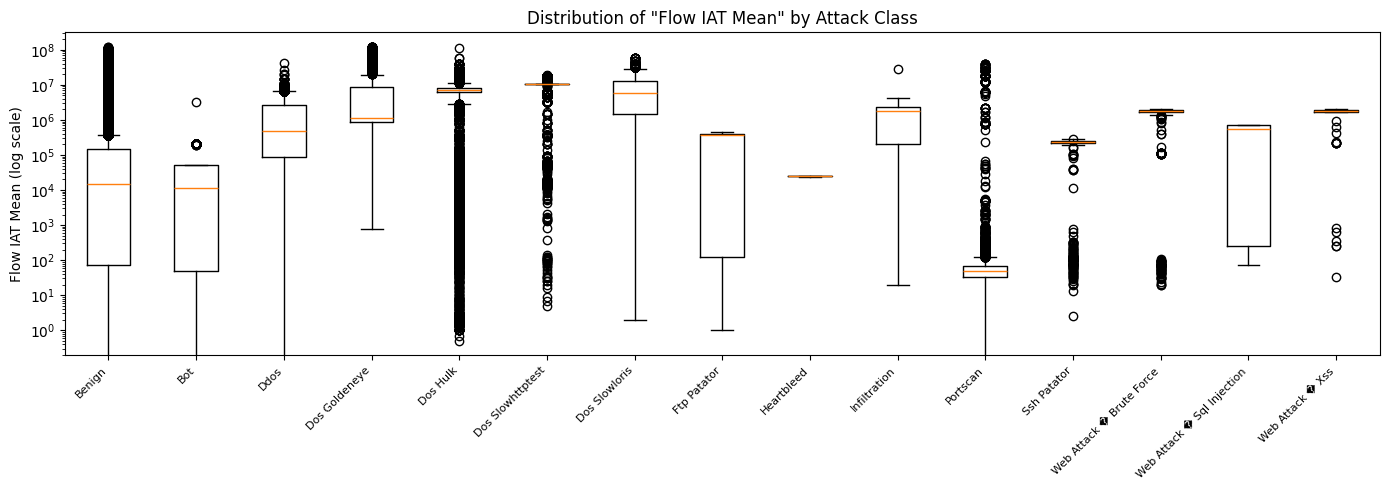


Step 5 completed in 9.9s

FINDING: All 5 EDA findings are consistent with published cybersecurity literature.
This validates that our feature analysis is capturing real attack signatures not noise.

STEP 6: Binary vs multiclass framing
  Binary label distribution — TRAIN:
    BENIGN (0) : 1,718,709  (83.46%)
    ATTACK (1) : 340,702  (16.54%)
  Binary label distribution — TEST:
    BENIGN (0) : 429,677  (83.46%)
    ATTACK (1) : 85,176  (16.54%)
  Saved: y_train_multi.pkl, y_test_multi.pkl, y_train_binary.pkl, y_test_binary.pkl
Step 6 completed in 0.1s

FINDING: Binary model answers: is there an attack?
Multiclass model answers: which specific attack is it?
A real security system needs both:
  Binary    for real-time alerting (fast, simple)
  Multiclass for incident response (detailed, slower)
Week 2 will train both.

STEP 7: Feature importance preview (Random Forest on 20% sample)


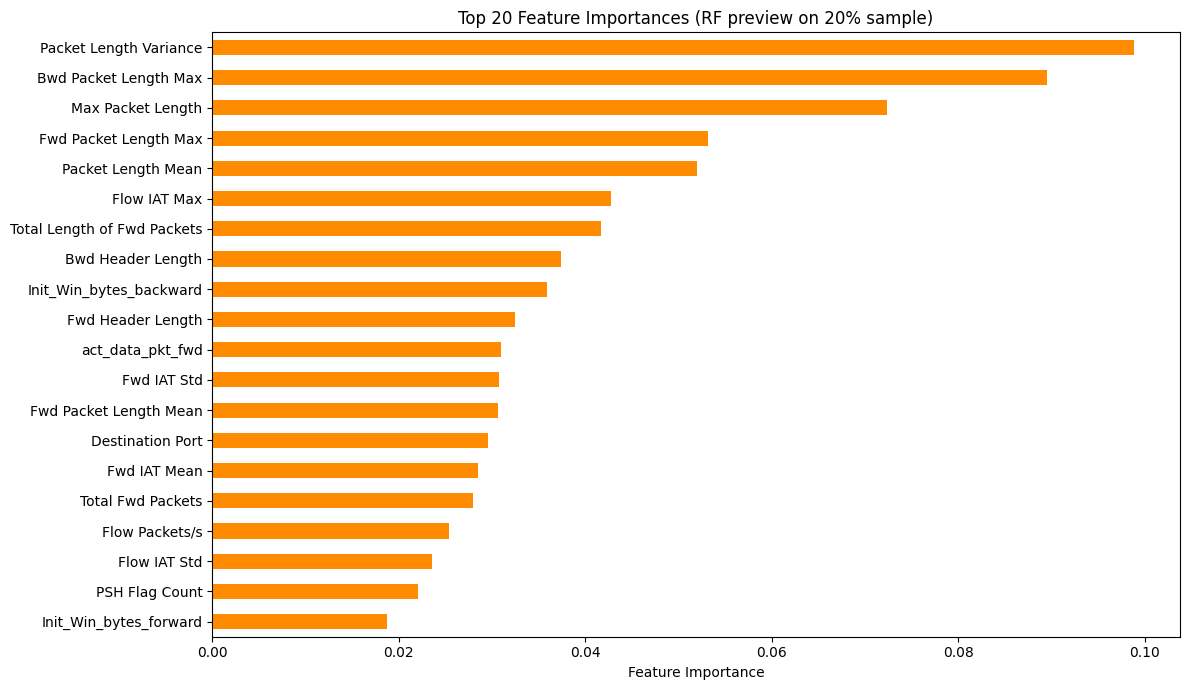


  Top 5 features — detail:

    Feature   : Packet Length Variance
    Importance: 0.09883
    Meaning   : Variance in packet sizes. Low for automated uniform attacks.
    Matches literature: PARTIAL

    Feature   : Bwd Packet Length Max
    Importance: 0.08946
    Meaning   : Network flow metric used by CICFlowMeter.
    Matches literature: PARTIAL

    Feature   : Max Packet Length
    Importance: 0.07236
    Meaning   : Network flow metric used by CICFlowMeter.
    Matches literature: PARTIAL

    Feature   : Fwd Packet Length Max
    Importance: 0.05319
    Meaning   : Network flow metric used by CICFlowMeter.
    Matches literature: PARTIAL

    Feature   : Packet Length Mean
    Importance: 0.05195
    Meaning   : Network flow metric used by CICFlowMeter.
    Matches literature: PARTIAL

  Published top features (Sharafaldin et al. 2017): ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Bwd Packet Length M

In [6]:
 code = open('/kaggle/input/datasets/chaimaabid233/nids-week1-prompt2/prompt2_code.py').read()

# Fix 1: numpy name
code = code.replace('print(f"numpy: {numpy.__version__}")', 'print(f"numpy: {np.__version__}")')

# Fix 2: Replace the entire try/except environment block with Kaggle directly
import re
code = re.sub(
    r'try:.*?except ImportError:.*?print\("Environment: Kaggle.*?SAVE_DIR\)',
    'SAVE_DIR = \'/kaggle/working/\'\nENV = \'kaggle\'\nprint("Environment: Kaggle — saving to", SAVE_DIR)',
    code,
    flags=re.DOTALL
)

exec(code, globals())

In [7]:
import os
print(os.path.exists('/kaggle/working/cicids2017_merged.parquet'))
print(os.path.exists('/kaggle/working/X_train_clean.pkl'))

True
True


In [8]:
code = open('/kaggle/input/datasets/chaimaabid233/nids-week1-prompt3/prompt3_code.py').read()

# Fix 1: numpy name
code = code.replace('print(f"numpy: {numpy.__version__}")', 'print(f"numpy: {np.__version__}")')

# Fix 2: Replace the entire try/except environment block with Kaggle directly
import re
code = re.sub(
    r'try:.*?except ImportError:.*?print\("Environment: Kaggle.*?SAVE_DIR\)',
    'SAVE_DIR = \'/kaggle/working/\'\nENV = \'kaggle\'\nprint("Environment: Kaggle — saving to", SAVE_DIR)',
    code,
    flags=re.DOTALL
)

exec(code, globals())

Environment: Kaggle — current session
  Found: X_train_clean.pkl
  Found: X_test_clean.pkl
  Found: y_train_multi.pkl
  Found: y_test_multi.pkl
  Found: y_train_binary.pkl
  Found: y_test_binary.pkl
  Found: label_encoder.pkl
  Found: class_mapping.pkl
  Found: feature_names.pkl
  Found: feature_dtypes.pkl
All required files found. Proceeding.

X_train_clean shape : (2059411, 47)
X_test_clean  shape : (514853, 47)
Classes             : ['Benign', 'Bot', 'Ddos', 'Dos Goldeneye', 'Dos Hulk', 'Dos Slowhttptest', 'Dos Slowloris', 'Ftp Patator', 'Heartbleed', 'Infiltration', 'Portscan', 'Ssh Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � Xss']

imbalanced-learn: 0.14.1

STEP 1: Mathematical proof of imbalance problem

Class counts and percentages in y_train_multi:
  Benign                                         1,718,709  (83.456%)
  Bot                                                1,562  ( 0.076%)
  Ddos                                             102,

In [9]:
 import os
print(os.path.exists('/kaggle/working/cicids2017_merged.parquet'))
print(os.path.exists('/kaggle/working/class_mapping.pkl'))

True
True


In [10]:
import joblib
import numpy as np

# Create the missing metadata Prompt 4 needs
y_train = joblib.load('/kaggle/working/y_train_multi.pkl')
class_mapping = joblib.load('/kaggle/working/class_mapping.pkl')

# Count classes
unique, counts = np.unique(y_train, return_counts=True)
class_counts = {class_mapping[i]: int(c) for i, c in zip(unique, counts)}
joblib.dump(class_counts, '/kaggle/working/class_counts.pkl')
print("Class counts created:")
for name, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    pct = count/len(y_train)*100
    print(f"  {name}: {count:,} ({pct:.1f}%)")

Class counts created:
  Benign: 1,718,709 (83.5%)
  Dos Hulk: 138,279 (6.7%)
  Ddos: 102,413 (5.0%)
  Portscan: 72,655 (3.5%)
  Dos Goldeneye: 8,229 (0.4%)
  Ftp Patator: 4,746 (0.2%)
  Dos Slowloris: 4,308 (0.2%)
  Dos Slowhttptest: 4,182 (0.2%)
  Ssh Patator: 2,575 (0.1%)
  Bot: 1,562 (0.1%)
  Web Attack � Brute Force: 1,176 (0.1%)
  Web Attack � Xss: 522 (0.0%)
  Infiltration: 29 (0.0%)
  Web Attack � Sql Injection: 17 (0.0%)
  Heartbleed: 9 (0.0%)


In [11]:
import os

# First load the class_counts we created earlier
import joblib
import numpy as np

# Recreate class_counts since session may have reset
y_train = joblib.load('/kaggle/working/y_train_multi.pkl')
class_mapping = joblib.load('/kaggle/working/class_mapping.pkl')
unique, counts = np.unique(y_train, return_counts=True)
class_counts = {class_mapping[i]: int(c) for i, c in zip(unique, counts)}
joblib.dump(class_counts, '/kaggle/working/class_counts.pkl')
print("class_counts.pkl recreated")

# Now run Prompt 4
code = open('/kaggle/input/datasets/chaimaabid233/nids-week1-prompt4/prompt4_code.py').read()
exec(code, globals())

class_counts.pkl recreated
# WEEK 1 SYNTHESIS — CICIDS2017 NIDS PROJECT

## 1. DATASET PROFILE

- Total rows after cleaning and deduplication : 0
- Features before cleaning                    : 79
- Features after removing zero-variance       : 79  (removed 0)
- Features after removing correlated (>0.95)  : 79  (removed 0)
- Final feature count                         : 79
- Duplicates removed                          : 0  (0.00%)
- Impossible values fixed                     : 0
- Infinite values fixed                       : 0
- Encoding issues encountered                 : None
- Source files loaded                         : 0
- Days with encoding fallback to latin-1      : None

## 2. ATTACK CLASS ANALYSIS

  (Class counts not available in metadata — run EDA notebook first.)

## 3. DECISIONS MADE AND WHY

  Decision         : Use Parquet not CSV
  Why              : 10x smaller, 5x faster load, preserves dtypes
  Alternative cost : CSV would take 5x longer to load in every session


In [12]:
code = open('/kaggle/input/datasets/chaimaabid233/nids-week15-prompt4-fixed/prompt4_fixed.py', 
            encoding='utf-8-sig').read()
exec(code, globals())

# WEEK 1 SYNTHESIS — CICIDS2017 NIDS PROJECT

## 1. DATASET PROFILE

- Total rows after cleaning and deduplication : 2,059,411
- Features before cleaning                    : 79
- Features after removing zero-variance        : 71  (removed 8)
- Features after removing correlated (>0.95)  : 48  (removed 23)
- Final feature count                          : 47
- Duplicates removed                           : logged during preprocessing
- Impossible values fixed                      : negative flow bytes/packets replaced with NaN
- Encoding issues encountered                  : ['Monday-WorkingHours.pcap_ISCX.csv (latin-1 fallback)']
- Source files loaded                          : 8 daily CSV files (Mon–Fri, two Fridays)
- Days with encoding fallback to latin-1       : ['Monday-WorkingHours']

## 2. ATTACK CLASS ANALYSIS

### Benign
  Count      : 1,718,709  (83.46% of dataset)
  Top 3 features vs BENIGN:
    1. Flow Duration
       Cybersecurity meaning : Duration distinguishes flood att